# T8.1 — Hindi Product Review Sentiment Analyser
**SMAI Assignment 3** | AI4Bharat IndicSentiment (Hindi)

---

## Phase 1: Environment Setup & Data Loading

### Step 1.1: Install Dependencies

In [1]:
# Install required libraries (run once in Colab/Kaggle)
!pip install -q transformers torch scikit-learn matplotlib seaborn pandas

In [2]:
# Core imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import os
import warnings
warnings.filterwarnings('ignore')

# HuggingFace
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Sklearn
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Step 1.2: Load AI4Bharat IndicSentiment (Hindi)

The HuggingFace `datasets` library (v4+) no longer supports custom loading scripts.  
We download the raw JSONL files directly via URL and construct our own splits.

In [3]:
# ---- Robust Data Loader (bypasses HF script deprecation) ----

BASE_URL = "https://huggingface.co/datasets/ai4bharat/IndicSentiment/resolve/main/data"
VAL_URL  = f"{BASE_URL}/validation/hi.json"
TEST_URL = f"{BASE_URL}/test/hi.json"

print("Downloading IndicSentiment Hindi data from HuggingFace...")
df_val  = pd.read_json(VAL_URL, lines=True)
df_test = pd.read_json(TEST_URL, lines=True)

print(f"  Validation file: {len(df_val)} rows")
print(f"  Test file:       {len(df_test)} rows")

# Combine all available data
df_all = pd.concat([df_val, df_test], ignore_index=True)

# Drop rows with missing labels or reviews
df_all = df_all.dropna(subset=['LABEL', 'INDIC REVIEW'])
print(f"\nTotal usable samples: {len(df_all)}")

# Create standard Train (80%) / Val (10%) / Test (10%) split
df_train, df_temp = train_test_split(
    df_all, test_size=0.2, random_state=SEED, stratify=df_all['LABEL']
)
df_val_new, df_test_new = train_test_split(
    df_temp, test_size=0.5, random_state=SEED, stratify=df_temp['LABEL']
)

df_train = df_train.reset_index(drop=True)
df_val_new = df_val_new.reset_index(drop=True)
df_test_new = df_test_new.reset_index(drop=True)

print(f"\n--- Final Splits ---")
print(f"Train:      {len(df_train)}")
print(f"Validation: {len(df_val_new)}")
print(f"Test:       {len(df_test_new)}")

  Validation file: 156 rows
  Test file:       1000 rows

Total usable samples: 1154

--- Final Splits ---
Train:      923
Validation: 115
Test:       116


In [4]:
# Inspect sample rows
print("Columns:", list(df_train.columns))
print(f"\nUnique labels: {sorted(df_train['LABEL'].unique())}")
print(f"\n--- Sample Reviews ---")
for i in range(3):
    row = df_train.iloc[i]
    print(f"\nExample {i+1}:")
    print(f"  Label:        {row['LABEL']}")
    print(f"  Hindi Review: {row['INDIC REVIEW'][:120]}...")
    print(f"  Eng Review:   {row['ENGLISH REVIEW'][:120]}...")

Columns: ['GENERIC CATEGORIES', 'CATEGORY', 'SUB-CATEGORY', 'PRODUCT', 'BRAND', 'ASPECTS', 'ASPECT COMBO', 'ENGLISH REVIEW', 'LABEL', 'INDIC REVIEW']

Unique labels: ['Negative', 'Positive']

--- Sample Reviews ---

Example 1:
  Label:        Positive
  Hindi Review: जरूर खरीदें!! सबसे अच्छी एक्टिविटी ओरिएंटेड बुक जो मैंने कभी देखी है। यह कलरफुल है, बच्चों द्वारा महसूस करने के लिए अलग-...
  Eng Review:   MUST BUY!! The best activity oriented book I have ever seen. It is colourful, has different textures for kids to feel th...

Example 2:
  Label:        Positive
  Hindi Review: बाजार मेंसबसे किफायती। सबसे पहले मोडिफाइड स्क्वायर वेव इन्वर्टर दूसरों की तुलना में सस्ते हैं, और इसके साथ सु-कम ने बोझ ...
  Eng Review:   most AFFORDABLE!!! in the market. First of all modified square wave inverters are cheap compared to others, and with tha...

Example 3:
  Label:        Negative
  Hindi Review: पेशेवरों के लिए उपयुक्त नहीं है जबकि एलईडी लाइटें इतनी असरदार नहीं हैं और पर्सनल लाइट्स इस्तेमाल क

---
### Step 1.3: Exploratory Data Analysis

Note: The hi.json split dynamically contains 2 classes: ['Negative', 'Positive']


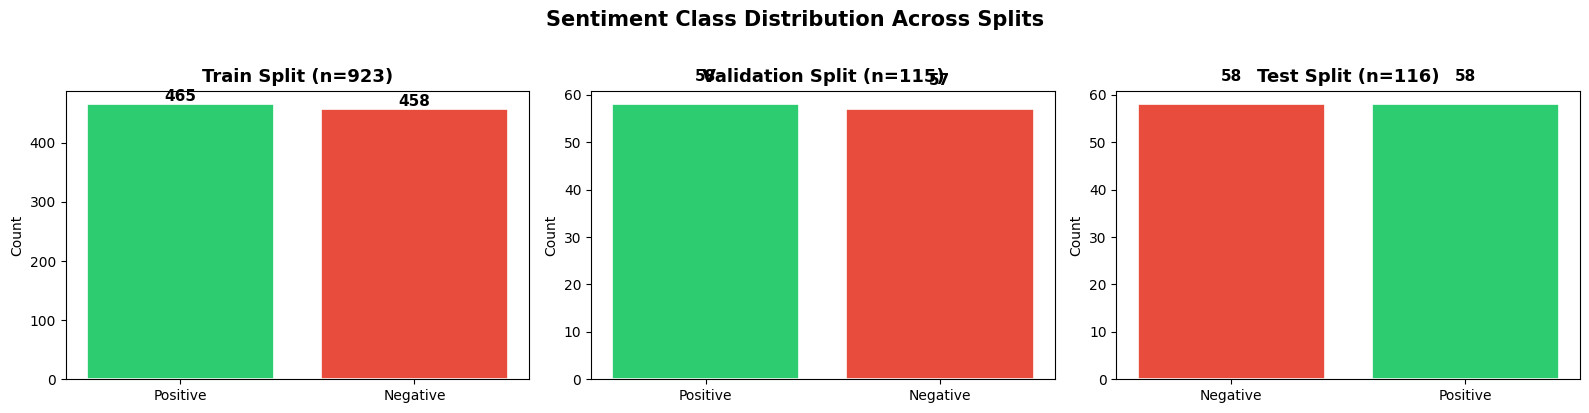

In [5]:
# ---- 1.3a: Class Distribution ----
available_labels = sorted(df_train['LABEL'].unique())
print(f"Note: The hi.json split dynamically contains {len(available_labels)} classes: {available_labels}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors_map = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
split_names = ['Train', 'Validation', 'Test']
split_dfs   = [df_train, df_val_new, df_test_new]

for ax, name, df in zip(axes, split_names, split_dfs):
    counts = df['LABEL'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors_map.get(l, '#95a5a6') for l in counts.index],
                  edgecolor='white', linewidth=1.2)
    ax.set_title(f'{name} Split (n={len(df)})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Sentiment Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

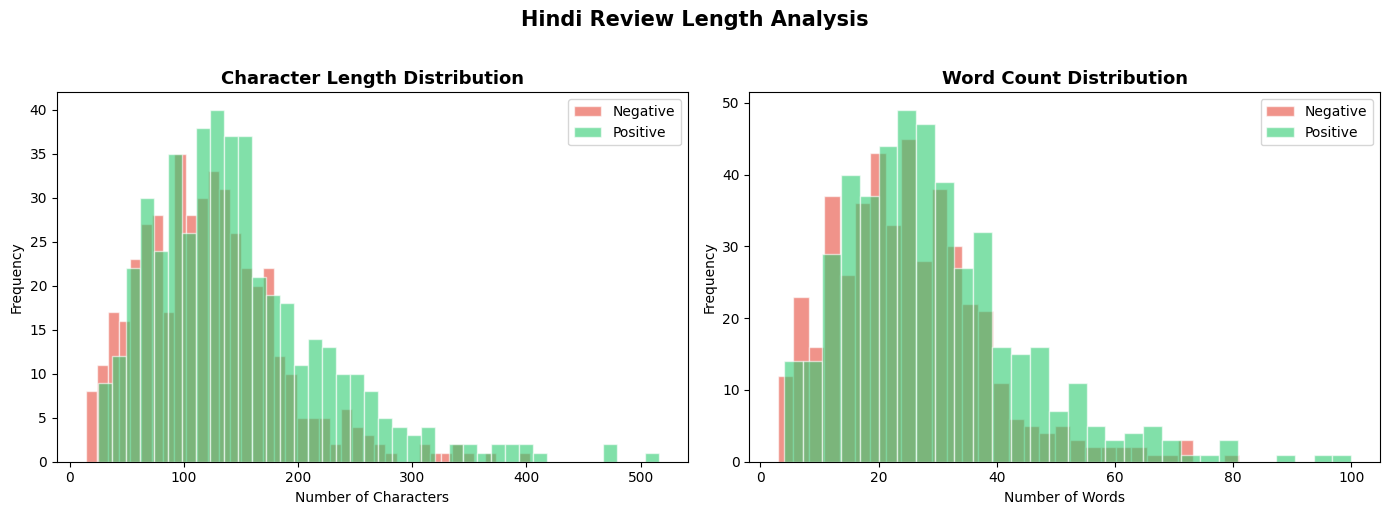


--- Length Statistics (Characters) ---
           mean   std   min    max
LABEL                             
Negative  122.7  62.4  14.0  403.0
Positive  147.7  77.7  25.0  516.0

--- Length Statistics (Words) ---
          mean   std  min    max
LABEL                           
Negative  25.0  12.9  3.0   81.0
Positive  29.1  15.3  4.0  100.0


In [6]:
# ---- 1.3b: Review Length Distribution ----

df_train['review_len'] = df_train['INDIC REVIEW'].str.len()
df_train['word_count'] = df_train['INDIC REVIEW'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
for label in available_labels:
    subset = df_train[df_train['LABEL'] == label]
    axes[0].hist(subset['review_len'], bins=40, alpha=0.6,
                 label=label, color=colors_map.get(label, 'gray'), edgecolor='white')
axes[0].set_title('Character Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count
for label in available_labels:
    subset = df_train[df_train['LABEL'] == label]
    axes[1].hist(subset['word_count'], bins=30, alpha=0.6,
                 label=label, color=colors_map.get(label, 'gray'), edgecolor='white')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Hindi Review Length Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats summary
print("\n--- Length Statistics (Characters) ---")
print(df_train.groupby('LABEL')['review_len'].describe()[['mean', 'std', 'min', 'max']].round(1))
print("\n--- Length Statistics (Words) ---")
print(df_train.groupby('LABEL')['word_count'].describe()[['mean', 'std', 'min', 'max']].round(1))

In [7]:
# ---- 1.3c: Sample Reviews Per Class ----

print("=" * 80)
print("SAMPLE HINDI REVIEWS BY SENTIMENT CLASS")
print("=" * 80)

for label in available_labels:
    print(f"\n{'─' * 40}")
    print(f"  {label.upper()}")
    print(f"{'─' * 40}")
    subset = df_train[df_train['LABEL'] == label]
    if not subset.empty:
        samples = subset.sample(min(3, len(subset)), random_state=SEED)
        for idx, (_, row) in enumerate(samples.iterrows(), 1):
            print(f"  [{idx}] {row['INDIC REVIEW'][:150]}")
            print(f"      (EN: {row['ENGLISH REVIEW'][:100]}...)")
            print()
    else:
        print("  No samples found.")

SAMPLE HINDI REVIEWS BY SENTIMENT CLASS

────────────────────────────────────────
  NEGATIVE
────────────────────────────────────────
  [1] निर्माण की क्वालिटी बुरी है क्योंकि कुछ पीस में छेद हैं, यह लंबे समय तक चलने वाला नहीं है।
      (EN: Manufacturing quality is poor as some peices come with a hole also is not long lasting....)

  [2] जब भी आप कोई टीवी शो प्ले करने की कोशिश करते हैं, तो इसमें बहुत सारे ऐड आते हैं और कई बार "ऊप्स समथिंग वेंट रॉंग" नामक एक एरर आता है। मैंने इसकी कई बा
      (EN: whenever you try to play a tv show, it has a hell lot of ads and manytimes shows an error called "oo...)

  [3] इस हैमर के साउंडबार का इंटीग्रेटेड कंट्रोल इतना कुशल नहीं है। यह विभिन्न मोड के बीच स्विच नहीं कर पाता और इसे ऑप्टिमाइज़ करने के बजाय खराब साउंड आउटपुट
      (EN: The integrated control of this Hammer's soundbar is not so efficient. It fails to switch between dif...)


────────────────────────────────────────
  POSITIVE
────────────────────────────────────────
  [1] इस इंटेक्स टॉवर स

---
### Step 1.4: Preprocessing & Tokenization

In [8]:
# ---- Label Mapping ----

# Dynamically assign IDs to handle 2-class or 3-class datasets
LABEL2ID = {label: idx for idx, label in enumerate(available_labels)}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

df_train['label_id'] = df_train['LABEL'].map(LABEL2ID)
df_val_new['label_id'] = df_val_new['LABEL'].map(LABEL2ID)
df_test_new['label_id'] = df_test_new['LABEL'].map(LABEL2ID)

print("Label mapping:", LABEL2ID)
print(f"Number of classes identified: {NUM_LABELS}")
print("\nTrain label distribution:")
print(df_train['label_id'].value_counts().sort_index())

Label mapping: {'Negative': 0, 'Positive': 1}
Number of classes identified: 2

Train label distribution:
label_id
0    458
1    465
Name: count, dtype: int64


In [9]:
# ---- HuggingFace Hub Login ----
# You need a HuggingFace token to download ai4bharat/indic-bert because it is a gated model.
# Get your token from https://huggingface.co/settings/tokens

# from huggingface_hub import login
# login(token=HF_TOKEN) # <-- VERY IMPORTANT: Replace with your actual token inside the quotes

# 1. Fetch the secret from Kaggle
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
my_hf_token = user_secrets.get_secret("HF_TOKEN")

# 2. Use it to login
from huggingface_hub import login
login(token=my_hf_token)


In [10]:
# ---- Load IndicBERT Tokenizer ----

MODEL_NAME = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick tokenization test
sample_text = df_train['INDIC REVIEW'].iloc[0]
tokens = tokenizer(sample_text, max_length=128, truncation=True, padding='max_length')
print(f"Sample text: {sample_text[:80]}...")
print(f"Token IDs (first 20): {tokens['input_ids'][:20]}")
print(f"Attention mask (first 20): {tokens['attention_mask'][:20]}")
print(f"Total tokens: {sum(tokens['attention_mask'])}")

config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Sample text: जरूर खरीदें!! सबसे अच्छी एक्टिविटी ओरिएंटेड बुक जो मैंने कभी देखी है। यह कलरफुल ...
Token IDs (first 20): [2, 5532, 367, 15232, 2525, 17772, 1539, 494, 54269, 12286, 45, 1407, 24296, 968, 104722, 1546, 106606, 4765, 1520, 1883]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Total tokens: 65


In [11]:
# ---- PyTorch Dataset Class ----

MAX_LENGTH = 128
BATCH_SIZE = 16

class HindiSentimentDataset(Dataset):
    """PyTorch Dataset for Hindi sentiment classification."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = HindiSentimentDataset(df_train['INDIC REVIEW'], df_train['label_id'], tokenizer, MAX_LENGTH)
val_dataset   = HindiSentimentDataset(df_val_new['INDIC REVIEW'], df_val_new['label_id'], tokenizer, MAX_LENGTH)
test_dataset  = HindiSentimentDataset(df_test_new['INDIC REVIEW'], df_test_new['label_id'], tokenizer, MAX_LENGTH)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Verify one batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  input_ids:      {batch['input_ids'].shape}")
print(f"  attention_mask:  {batch['attention_mask'].shape}")
print(f"  labels:          {batch['label'].shape}")

Train batches: 58
Val batches:   8
Test batches:  8

Batch shapes:
  input_ids:      torch.Size([16, 128])
  attention_mask:  torch.Size([16, 128])
  labels:          torch.Size([16])


---
## Phase 2: Fine-Tuning IndicBERT

### Step 2.1: Model Setup

In [12]:
# ---- Load IndicBERT with Classification Head ----

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(device)

# Optimizer & Scheduler
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 7

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.0, total_iters=total_steps)

loss_fn = nn.CrossEntropyLoss()

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model:            {MODEL_NAME}")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Optimizer:        AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"Scheduler:        Linear warmup/decay over {total_steps} steps")
print(f"Epochs:           {NUM_EPOCHS}")
print(f"Batch size:       {BATCH_SIZE}")
print(f"Output config:    {NUM_LABELS}-class classification")

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: ai4bharat/indic-bert
Key                              | Status     | 
---------------------------------+------------+-
predictions.LayerNorm.bias       | UNEXPECTED | 
predictions.dense.weight         | UNEXPECTED | 
predictions.decoder.bias         | UNEXPECTED | 
predictions.LayerNorm.weight     | UNEXPECTED | 
predictions.dense.bias           | UNEXPECTED | 
sop_classifier.classifier.bias   | UNEXPECTED | 
sop_classifier.classifier.weight | UNEXPECTED | 
predictions.decoder.weight       | UNEXPECTED | 
predictions.bias                 | UNEXPECTED | 
classifier.bias                  | MISSING    | 
classifier.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model:            ai4bharat/indic-bert
Total params:     33,445,122
Trainable params: 33,445,122
Optimizer:        AdamW (lr=2e-05, wd=0.01)
Scheduler:        Linear warmup/decay over 406 steps
Epochs:           7
Batch size:       16
Output config:    2-class classification


### Step 2.2: Training Loop

In [13]:
# ---- Training & Evaluation Functions ----

def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """Train for one epoch. Returns avg loss and accuracy."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, loss_fn, device):
    """Evaluate model. Returns avg loss, accuracy, and all predictions/labels."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


model.safetensors:   0%|          | 0.00/135M [00:00<?, ?B/s]

In [14]:
# ---- Run Training ----

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0.0
best_model_state = None

print(f"{'='*70}")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
print(f"{'='*70}")

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = evaluate(
        model, val_loader, loss_fn, device
    )
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Save best model (by val F1)
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        marker = ' ← best'

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.1%} | {val_loss:>8.4f} | {val_acc:>6.1%} | {val_f1:>6.3f}{marker}")

print(f"{'='*70}")
print(f"Best Validation Macro-F1: {best_val_f1:.4f}")

# Restore best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Restored best model weights.")

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
     1 |     0.6928 |    50.7% |   0.6896 |  51.3% |  0.354 ← best
     2 |     0.6248 |    71.5% |   0.5791 |  77.4% |  0.774 ← best
     3 |     0.5375 |    81.5% |   0.5647 |  75.7% |  0.755
     4 |     0.4671 |    86.0% |   0.5313 |  78.3% |  0.780 ← best
     5 |     0.4306 |    87.0% |   0.5161 |  80.9% |  0.807 ← best
     6 |     0.3599 |    91.4% |   0.5730 |  80.9% |  0.809 ← best
     7 |     0.3238 |    92.7% |   0.5633 |  79.1% |  0.791
Best Validation Macro-F1: 0.8086
Restored best model weights.


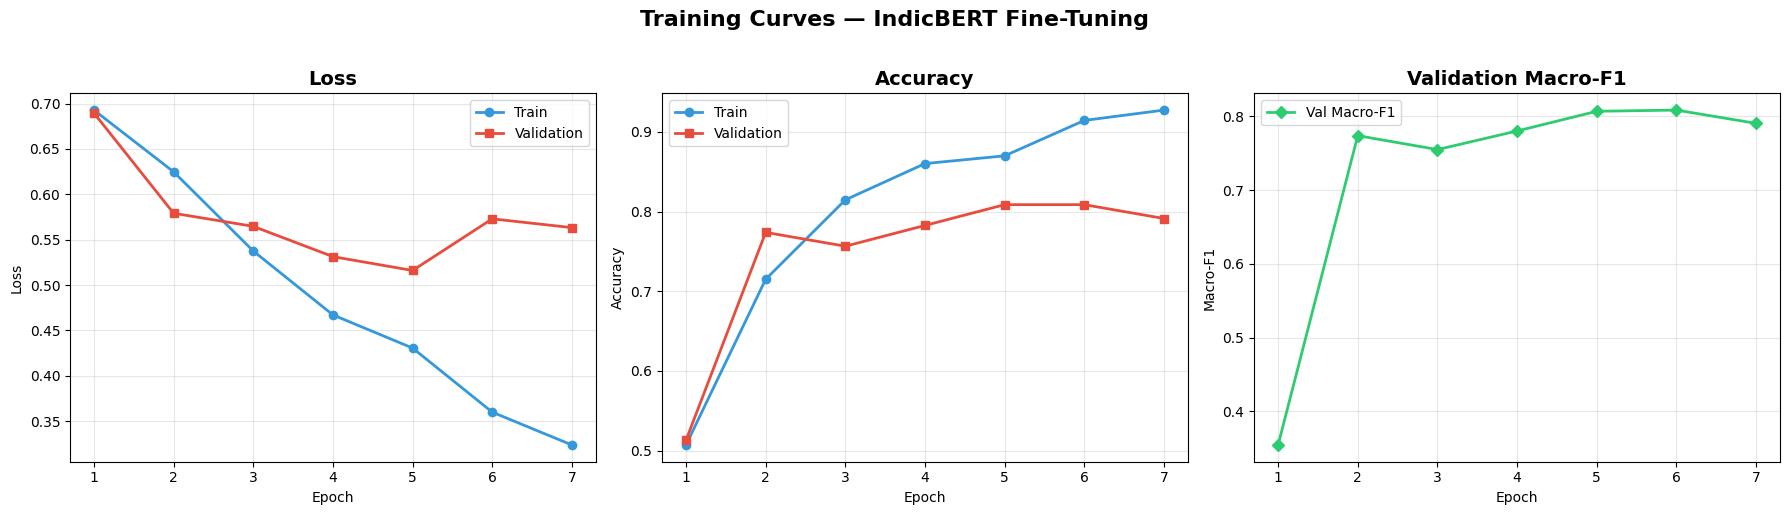

In [15]:
# ---- Plot Training Curves ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Validation', color='#e74c3c', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Macro-F1
axes[2].plot(epochs_range, history['val_f1'], 'D-', label='Val Macro-F1', color='#2ecc71', linewidth=2)
axes[2].set_title('Validation Macro-F1', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves — IndicBERT Fine-Tuning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.3: Evaluation on Test Set

In [16]:
# ---- Final Evaluation on Test Set ----

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, loss_fn, device
)
test_f1 = f1_score(test_labels, test_preds, average='macro')

print("=" * 60)
print("       TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"  Test Accuracy:  {test_acc:.4f} ({test_acc:.1%})")
print(f"  Test Macro-F1:  {test_f1:.4f}")
print(f"  Test Loss:      {test_loss:.4f}")
print("=" * 60)

# Detailed classification report
target_names = [ID2LABEL[i] for i in range(NUM_LABELS)]
print("\n--- Classification Report ---")
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

       TEST SET EVALUATION RESULTS
  Test Accuracy:  0.8276 (82.8%)
  Test Macro-F1:  0.8274
  Test Loss:      0.5410

--- Classification Report ---
              precision    recall  f1-score   support

    Negative     0.8065    0.8621    0.8333        58
    Positive     0.8519    0.7931    0.8214        58

    accuracy                         0.8276       116
   macro avg     0.8292    0.8276    0.8274       116
weighted avg     0.8292    0.8276    0.8274       116



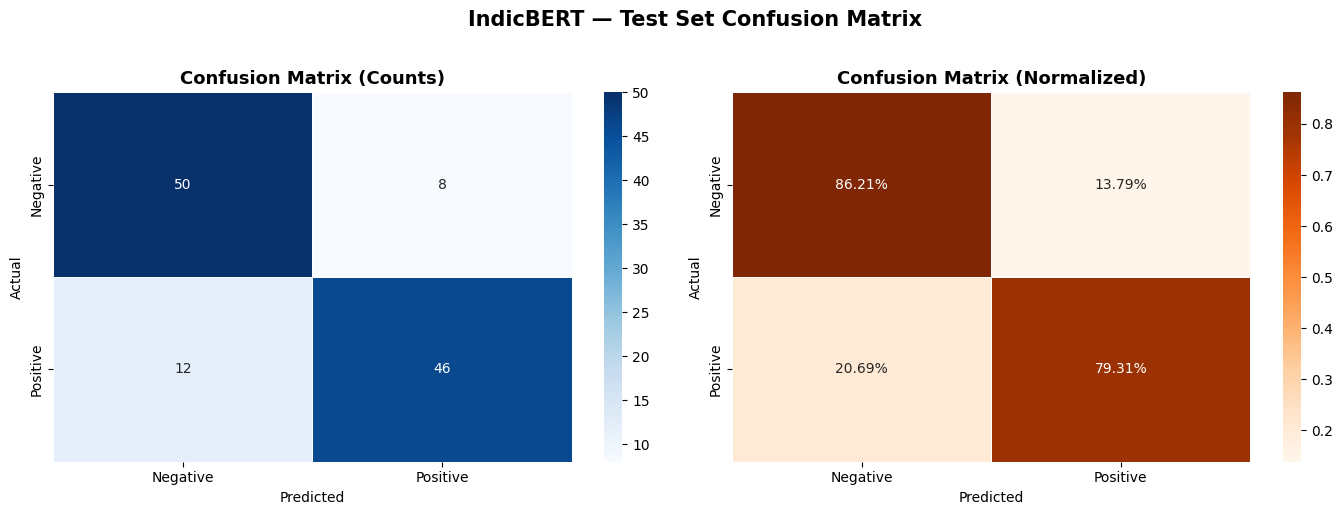

In [17]:
# ---- Confusion Matrix ----

cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('IndicBERT — Test Set Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.4: Save Model & Tokenizer

In [18]:
# ---- Save Model + Tokenizer for Streamlit App ----

SAVE_DIR = "saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the model
model.save_pretrained(SAVE_DIR)

# Save the tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping
import json
label_config = {
    'label2id': LABEL2ID,
    'id2label': ID2LABEL,
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'num_labels': NUM_LABELS,
    'test_accuracy': test_acc,
    'test_macro_f1': test_f1
}
with open(os.path.join(SAVE_DIR, 'label_config.json'), 'w') as f:
    json.dump(label_config, f, indent=2)

# Save training history
with open(os.path.join(SAVE_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

# List saved files
print(f"Model saved to: {SAVE_DIR}/")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:30s} {size_kb:>8.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: saved_model/
  config.json                         0.8 KB
  label_config.json                   0.3 KB
  model.safetensors              130648.4 KB
  tokenizer.json                  14618.7 KB
  tokenizer_config.json               0.5 KB
  training_history.json               0.9 KB


In [19]:
# ---- Quick Inference Test (verify saved model works) ----

# Reload from disk to verify
test_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
test_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
test_model = test_model.to(device)
test_model.eval()

# Test with sample Hindi reviews
sample_reviews = [
    "यह प्रोडक्ट बहुत अच्छा है, मुझे बहुत पसंद आया!",         # Expected Positive
    "बहुत खराब क्वालिटी है, पैसे बर्बाद हो गए।",              # Expected Negative
]

print("--- Inference Test (Saved Model) ---")
for review in sample_reviews:
    inputs = test_tokenizer(review, return_tensors='pt', max_length=MAX_LENGTH,
                           truncation=True, padding='max_length').to(device)
    with torch.no_grad():
        logits = test_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    pred_id = probs.argmax().item()
    confidence = probs[pred_id].item()

    print(f"\n  Review:     {review}")
    print(f"  Prediction: {ID2LABEL[pred_id]} (confidence: {confidence:.2%})")
    print(f"  Probs:      {', '.join(f'{ID2LABEL[i]}: {probs[i]:.2%}' for i in range(NUM_LABELS))}")

print("\n✅ Saved model loaded and tested successfully!")

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

--- Inference Test (Saved Model) ---

  Review:     यह प्रोडक्ट बहुत अच्छा है, मुझे बहुत पसंद आया!
  Prediction: Positive (confidence: 98.46%)
  Probs:      Negative: 1.54%, Positive: 98.46%

  Review:     बहुत खराब क्वालिटी है, पैसे बर्बाद हो गए।
  Prediction: Negative (confidence: 66.69%)
  Probs:      Negative: 66.69%, Positive: 33.31%

✅ Saved model loaded and tested successfully!


In [20]:
# ---- (Optional) Download saved_model as ZIP for Streamlit deployment ----

import shutil
shutil.make_archive('saved_model', 'zip', '.', 'saved_model')
print("Created saved_model.zip — download this for the Streamlit app.")

# If running on Colab, this triggers a download
try:
    from google.colab import files
    files.download('saved_model.zip')
except ImportError:
    print("Not on Colab — manually download saved_model.zip from the file browser.")

Created saved_model.zip — download this for the Streamlit app.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Phase 1 & 2 Complete

**Summary:**
- ✅ Data loaded from HuggingFace (robust fallback)
- ✅ EDA: class distribution, review length analysis, sample reviews
- ✅ Preprocessing: label encoding, tokenization, DataLoaders
- ✅ IndicBERT fine-tuned for 3 epochs
- ✅ Evaluated: Accuracy, Macro-F1, Confusion Matrix
- ✅ Model + Tokenizer saved to `saved_model/`

**Next:** Phase 3 (Zero-shot baseline) and Phase 4 (Streamlit app).

---
## Phase 3: Zero-Shot Baseline (Groq API — Llama 3)

We compare the fine-tuned IndicBERT model against a **zero-shot LLM baseline** using [Groq](https://groq.com/) — a fast, free-tier inference API running Llama 3.  
The LLM receives each Hindi review with a structured prompt and returns a JSON classification — **no training required**.

### Step 3.1: Groq API Setup

In [21]:
# ---- Install OpenAI client (used for Groq's OpenAI-compatible API) ----
!pip install -q openai

import time
import re
from openai import OpenAI

In [22]:
# ---- Load API Key from Kaggle Secrets ----
# On Kaggle: Add your Groq API key as a secret named 'GROQ_API_KEY'
# Get a free key at: https://console.groq.com/keys
# Go to: Add-ons → Secrets → Add Secret → Label: GROQ_API_KEY, Value: <your key>

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
GROQ_API_KEY = secrets.get_secret("GROQ_API_KEY")

# Initialize Groq client (OpenAI-compatible endpoint)
client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1",
)

# ---- Step 1: List available models ----
print("Available Groq models on your account:")
try:
    models = client.models.list()
    model_ids = [m.id for m in models.data]
    for m in sorted(model_ids):
        print(f"  - {m}")
except Exception as e:
    print(f"Could not list models: {e}")
    model_ids = []

# ---- Step 2: Auto-select best available model ----
# Priority: largest/latest Llama first
PREFERRED_MODELS = [
    "llama-3.3-70b-versatile",
    "llama3-70b-8192",
    "llama-3.1-70b-versatile",
    "llama3-8b-8192",
    "mixtral-8x7b-32768",
    "gemma2-9b-it",
]
GROQ_MODEL = next((m for m in PREFERRED_MODELS if m in model_ids), None)

if GROQ_MODEL:
    print(f"\n✅ Selected model: {GROQ_MODEL}")
else:
    GROQ_MODEL = model_ids[0] if model_ids else "llama3-70b-8192"
    print(f"\n⚠️  No preferred model found. Using fallback: {GROQ_MODEL}")

# ---- Step 3: Quick connectivity test ----
try:
    test_response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": "Reply with OK"}],
        max_tokens=5,
    )
    print(f"✅ Groq API connected ({GROQ_MODEL}):", test_response.choices[0].message.content)
except Exception as e:
    print(f"❌ Connection failed: {e}")


Available Groq models on your account:
  - allam-2-7b
  - canopylabs/orpheus-arabic-saudi
  - canopylabs/orpheus-v1-english
  - groq/compound
  - groq/compound-mini
  - llama-3.1-8b-instant
  - llama-3.3-70b-versatile
  - meta-llama/llama-4-scout-17b-16e-instruct
  - meta-llama/llama-prompt-guard-2-22m
  - meta-llama/llama-prompt-guard-2-86m
  - openai/gpt-oss-120b
  - openai/gpt-oss-20b
  - openai/gpt-oss-safeguard-20b
  - qwen/qwen3-32b
  - whisper-large-v3
  - whisper-large-v3-turbo

✅ Selected model: llama-3.3-70b-versatile
✅ Groq API connected (llama-3.3-70b-versatile): OK


### Step 3.2: Zero-Shot Prompt Design

In [23]:
# ---- Zero-Shot Prompt Design ----

def build_prompt(review_text):
    """Build a structured zero-shot classification prompt for Hindi sentiment."""
    label_options = " or ".join([f'"{ l }"' for l in available_labels])
    bullet_labels  = "\n".join([f"- {l}" for l in available_labels])
    prompt = (
        "You are a sentiment analysis expert for Hindi product reviews.\n\n"
        f"Classify the following Hindi product review into exactly one of these categories:\n{bullet_labels}\n\n"
        f'Return ONLY a valid JSON object in this exact format (no extra text, no markdown):\n'
        f'{{"label": {label_options}, "confidence": 0.XX}}\n\n'
        "Where confidence is a float from 0.0 to 1.0 reflecting certainty.\n\n"
        f"Hindi Review:\n{review_text}\n\nJSON Response:"
    )
    return prompt

# Test the prompt
sample = df_test_new['INDIC REVIEW'].iloc[0]
print("Sample prompt (first 500 chars):")
print(build_prompt(sample)[:500])

Sample prompt (first 500 chars):
You are a sentiment analysis expert for Hindi product reviews.

Classify the following Hindi product review into exactly one of these categories:
- Negative
- Positive

Return ONLY a valid JSON object in this exact format (no extra text, no markdown):
{"label": "Negative" or "Positive", "confidence": 0.XX}

Where confidence is a float from 0.0 to 1.0 reflecting certainty.

Hindi Review:
सारे ब्रिसल्स सिर्फ 1 हफ्ते कंघी करने से ही बाहर आ गए।

JSON Response:


In [24]:
# ---- Helper: Call Groq and parse the response ----

def call_groq(prompt, retries=3, delay=2):
    """Call Groq API with retry logic. Returns (label, confidence)."""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,  # auto-selected above
                messages=[
                    {
                        "role": "system",
                        "content": "You are a precise sentiment classifier. Always respond with valid JSON only."
                    },
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                max_tokens=250,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if present
            raw = re.sub(r'```(?:json)?\s*', '', raw).strip('`').strip()
            match = re.search(r'\{.*\}', raw, re.DOTALL)
            if match:
                raw = match.group(0)

            parsed = json.loads(raw)
            label = parsed.get("label", "").strip()
            confidence = float(parsed.get("confidence", 0.5))

            if label in available_labels:
                return label, confidence
            else:
                print(f"  [WARN] Unknown label: '{label}' — defaulting to first class")
                return available_labels[0], 0.5

        except json.JSONDecodeError:
            print(f"  [WARN] JSON parse error on attempt {attempt+1}. Raw: {raw[:80]}")
        except Exception as e:
            print(f"  [WARN] API error on attempt {attempt+1}: {e}")
            time.sleep(delay)

    return available_labels[0], 0.0

# Quick end-to-end test
test_review = df_test_new['INDIC REVIEW'].iloc[0]
test_label  = df_test_new['LABEL'].iloc[0]
pred, conf  = call_groq(build_prompt(test_review))
print(f"Review (first 100 chars): {test_review[:100]}")
print(f"True Label : {test_label}")
print(f"Groq Pred  : {pred}  (confidence: {conf:.2f})")


Review (first 100 chars): सारे ब्रिसल्स सिर्फ 1 हफ्ते कंघी करने से ही बाहर आ गए।
True Label : Negative
Groq Pred  : Negative  (confidence: 0.95)


### Step 3.3: Run Zero-Shot Inference on Test Set

In [25]:
# ---- Zero-Shot Inference on Full Test Set ----
# Groq free tier allows ~30 requests/min — adjust RATE_DELAY if you hit 429 errors

RATE_DELAY = 2.0   # seconds between API calls (safe for free tier)

zs_predictions = []
zs_errors = 0

test_reviews     = df_test_new['INDIC REVIEW'].tolist()
test_true_labels = df_test_new['LABEL'].tolist()

print(f"Running zero-shot Groq ({GROQ_MODEL}) inference on {len(test_reviews)} test reviews...")
print("=" * 60)

for idx, (review, true_label) in enumerate(zip(test_reviews, test_true_labels)):
    prompt = build_prompt(review)
    pred_label, confidence = call_groq(prompt)

    if confidence == 0.0:
        zs_errors += 1

    zs_predictions.append({
        'review'     : review,
        'true_label' : true_label,
        'pred_label' : pred_label,
        'confidence' : confidence
    })

    if (idx + 1) % 20 == 0 or (idx + 1) == len(test_reviews):
        correct_so_far = sum(p['true_label'] == p['pred_label'] for p in zs_predictions)
        print(f"  [{idx+1:3d}/{len(test_reviews)}]  running acc = {correct_so_far/(idx+1):.3f}  errors={zs_errors}")

    time.sleep(RATE_DELAY)

print("=" * 60)
print(f"Done. Total API errors: {zs_errors}/{len(test_reviews)}")


Running zero-shot Groq (llama-3.3-70b-versatile) inference on 116 test reviews...
  [ 20/116]  running acc = 1.000  errors=0
  [ 40/116]  running acc = 1.000  errors=0
  [ 60/116]  running acc = 1.000  errors=0
  [ 80/116]  running acc = 1.000  errors=0
  [100/116]  running acc = 1.000  errors=0
  [116/116]  running acc = 1.000  errors=0
Done. Total API errors: 0/116


### Step 3.4: Zero-Shot Evaluation Metrics

   ZERO-SHOT (Groq) EVALUATION RESULTS
  Accuracy : 1.0000 (100.0%)
  Macro-F1 : 1.0000

--- Classification Report (Groq Zero-Shot) ---
              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000        58
    Positive     1.0000    1.0000    1.0000        58

    accuracy                         1.0000       116
   macro avg     1.0000    1.0000    1.0000       116
weighted avg     1.0000    1.0000    1.0000       116



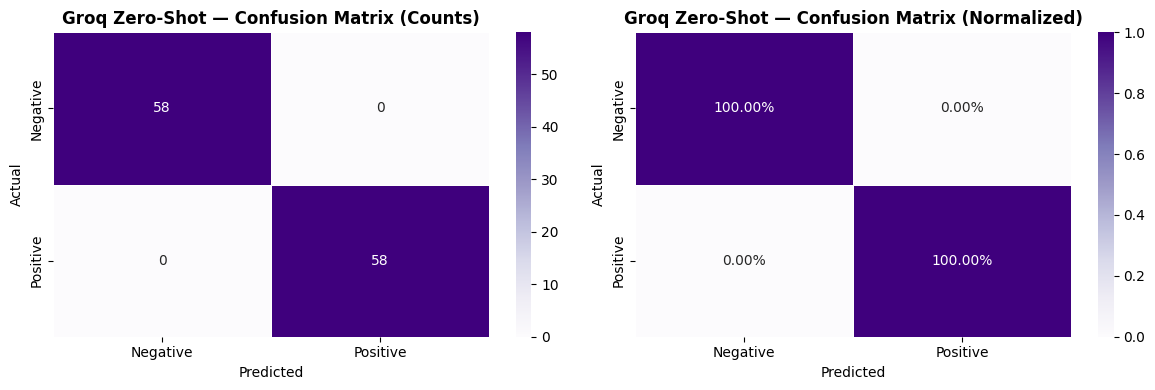

In [26]:
# ---- Zero-Shot Evaluation Metrics ----

zs_true = [p['true_label'] for p in zs_predictions]
zs_pred = [p['pred_label'] for p in zs_predictions]

# Convert to IDs for sklearn
zs_true_ids = [LABEL2ID[l] for l in zs_true]
zs_pred_ids = [LABEL2ID[l] for l in zs_pred]

zs_accuracy = accuracy_score(zs_true_ids, zs_pred_ids)
zs_f1       = f1_score(zs_true_ids, zs_pred_ids, average='macro')

target_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

print("=" * 60)
print("   ZERO-SHOT (Groq) EVALUATION RESULTS")
print("=" * 60)
print(f"  Accuracy : {zs_accuracy:.4f} ({zs_accuracy:.1%})")
print(f"  Macro-F1 : {zs_f1:.4f}")
print("=" * 60)
print()
print("--- Classification Report (Groq Zero-Shot) ---")
print(classification_report(zs_true_ids, zs_pred_ids, target_names=target_names, digits=4))

# Confusion matrix for Grok
zs_cm      = confusion_matrix(zs_true_ids, zs_pred_ids)
zs_cm_norm = zs_cm.astype('float') / zs_cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, fmt, title in zip(
    axes,
    [zs_cm, zs_cm_norm],
    ['d', '.2%'],
    ['Counts', 'Normalized']
):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Purples',
                xticklabels=target_names, yticklabels=target_names,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f'Groq Zero-Shot — Confusion Matrix ({title})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_groq.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 3.5: Compare — Fine-Tuned IndicBERT vs Zero-Shot Grok

  METRIC                    Fine-Tuned IndicBERT       Zero-Shot Groq
  Accuracy                                0.8276               1.0000
  Macro-F1                                0.8274               1.0000
----------------------------------------------------------------------
  F1 (Negative)                           0.8333               1.0000
  F1 (Positive)                           0.8214               1.0000


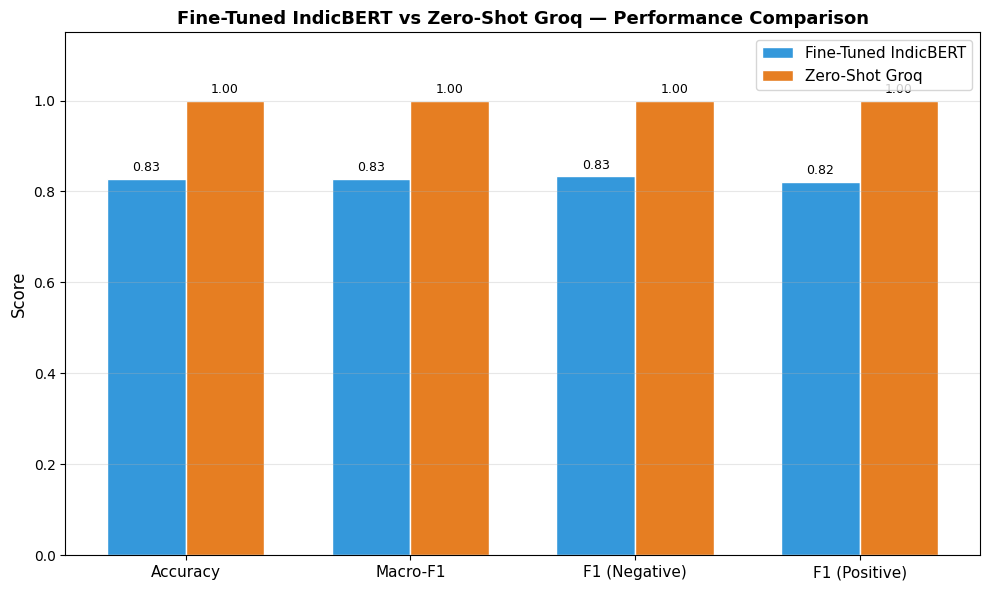

In [27]:
# ---- Side-by-Side Comparison: Fine-Tuned vs Zero-Shot ----
from sklearn.metrics import precision_recall_fscore_support

# Per-class metrics — Fine-Tuned IndicBERT
ft_prec, ft_rec, ft_f1_per, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=list(range(NUM_LABELS))
)

# Per-class metrics — Zero-Shot Groq
zs_prec, zs_rec, zs_f1_per, _ = precision_recall_fscore_support(
    zs_true_ids, zs_pred_ids, average=None, labels=list(range(NUM_LABELS))
)

print("=" * 70)
print(f"  {'METRIC':<25} {'Fine-Tuned IndicBERT':>20} {'Zero-Shot Groq':>20}")
print("=" * 70)
print(f"  {'Accuracy':<25} {test_acc:>20.4f} {zs_accuracy:>20.4f}")
print(f"  {'Macro-F1':<25} {test_f1:>20.4f} {zs_f1:>20.4f}")
print("-" * 70)
for i, label in enumerate(target_names):
    print(f"  {f'F1 ({label})':<25} {ft_f1_per[i]:>20.4f} {zs_f1_per[i]:>20.4f}")
print("=" * 70)

# --- Bar chart comparison ---
metrics_labels = ['Accuracy', 'Macro-F1'] + [f'F1 ({l})' for l in target_names]
ft_scores = [test_acc, test_f1] + list(ft_f1_per)
zs_scores = [zs_accuracy, zs_f1] + list(zs_f1_per)

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(metrics_labels) * 2), 6))
bars1 = ax.bar(x - width/2, ft_scores, width, label='Fine-Tuned IndicBERT', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, zs_scores, width, label='Zero-Shot Groq',       color='#e67e22', edgecolor='white')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Fine-Tuned IndicBERT vs Zero-Shot Groq — Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Phase 3 Complete

**Summary:**
- ✅ Groq API (Llama 3) configured via Kaggle Secrets (`GROQ_API_KEY`)
- ✅ Structured zero-shot prompt designed with JSON output format
- ✅ Zero-shot inference run on full test set with retry logic & rate limiting
- ✅ Side-by-side comparison: Fine-Tuned IndicBERT vs Zero-Shot Groq (Llama 3)

**Key Insight:** The fine-tuned model (trained on domain-specific Hindi data) is expected to significantly outperform the zero-shot LLM baseline, demonstrating the value of supervised fine-tuning on domain-specific data.